# 07 — Optimize local baseline removal for impulsive airwaves

This notebook follows the reduced-time event-association and filter-bank
experiments, but it deliberately applies **no Butterworth filtering**.

The objective is to estimate and remove the local pressure baseline while
preserving the physical waveform amplitude and shape. Two baseline approaches
are compared:

1. a long-window moving median, used primarily to obtain provisional peaks;
2. an iterative local linear baseline fitted to samples before and after a
   provisional one-cycle event window.

For a positive peak at time \(A\) followed by a negative peak at time \(B\),

\[
T_{1/2}=B-A,
\]

and the provisional full-cycle interval is

\[
t_\mathrm{start}=A-\frac{1}{2}T_{1/2},
\qquad
t_\mathrm{end}=B+\frac{1}{2}T_{1/2}.
\]

The local linear baseline is fitted outside this event interval, using short
pre-event and post-event baseline windows. Peaks and event boundaries are then
remeasured relative to that fitted baseline.

## Main outputs

For each selected event and channel, the notebook records:

- provisional and refined positive-peak times and amplitudes;
- provisional and refined negative-peak times and amplitudes;
- positive-to-negative lag;
- peak-to-peak pressure;
- provisional and refined event start/end times;
- event duration;
- local baseline intercept and slope;
- pre-event and post-event robust noise;
- baseline-fit residual;
- pressure impulse;
- method and quality flags.

It also generates detailed diagnostic PNGs for the clearest events.

## 1. Imports and project paths

In [12]:
from pathlib import Path
from collections.abc import Mapping
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from obspy import Stream, Trace, UTCDateTime, read

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]

REDUCED_REVIEW_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "event_waveform_review_reduced_time"
)
FILTER_OPTIMIZATION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "highpass_filter_optimization"
)

EVENT_FILE = (
    REDUCED_REVIEW_DIR
    / "derived"
    / "reconstructed_reduced_time_events_with_legacy_matches.csv"
)
PICK_ASSIGNMENT_FILE = (
    REDUCED_REVIEW_DIR
    / "derived"
    / "reduced_time_pick_assignments.csv"
)
STACK_METRICS_FILE = REDUCED_REVIEW_DIR / "stack_metrics.csv"
SELECTED_FILTER_EVENTS_FILE = (
    FILTER_OPTIMIZATION_DIR
    / "derived"
    / "selected_filter_test_events.csv"
)
STREAM_FILE = DERIVED_DIR / "bchh_corrected_analysis_window.pkl"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "local_baseline_optimization"
EVENT_PLOT_DIR = OUTPUT_DIR / "event_diagnostics"
SUMMARY_PLOT_DIR = OUTPUT_DIR / "summary_figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    EVENT_PLOT_DIR,
    SUMMARY_PLOT_DIR,
    DERIVED_OUTPUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Output directory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/local_baseline_optimization


## 2. Configuration

In [13]:
INFRASOUND_CHANNELS = ("HD1", "HD2", "HD3")

BCHH_INFRASOUND_DISTANCES_M = {
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}
REFERENCE_CHANNEL = "HD2"
WIND_CORRECTED_ACOUSTIC_SPEED_MPS = 351.0

# Number of clearest events to visualize in detail.
MAX_SELECTED_EVENTS = 24

# Extract enough unfiltered data to support the moving median and exterior
# local-baseline windows.
EXTRACT_PRE_S = 0.60
EXTRACT_POST_S = 0.70

# Moving-median windows. They should be much longer than the pulse itself.
MOVING_MEDIAN_WINDOWS_S = (0.25, 0.50, 1.00)

# Initial search around the reduced event time.
INITIAL_SIGNAL_SEARCH_WINDOW_S = (-0.04, 0.22)

# Positive peak must precede the negative peak.
MINIMUM_POSITIVE_NEGATIVE_LAG_S = 0.004
MAXIMUM_POSITIVE_NEGATIVE_LAG_S = 0.18

# Initial sinusoidal full-cycle extension around the two peaks.
INITIAL_BOUNDARY_EXTENSION_FRACTION = 0.50

# Baseline fit windows are scaled by the positive-negative lag, but constrained
# to practical limits.
BASELINE_SIDE_WINDOW_MULTIPLIER = 0.75
MINIMUM_BASELINE_SIDE_WINDOW_S = 0.04
MAXIMUM_BASELINE_SIDE_WINDOW_S = 0.18
BASELINE_GAP_S = 0.008

# Boundary refinement: signal is considered to have returned to baseline when
# it remains below this multiple of robust local noise for N consecutive samples.
BOUNDARY_NOISE_MULTIPLIER = 2.0
BOUNDARY_CONSECUTIVE_SAMPLES = 3
MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S = 0.12

# Iterative local-baseline refinement.
MAXIMUM_ITERATIONS = 3
PEAK_TIME_CONVERGENCE_S = 0.004

# Diagnostic plots.
WRITE_EVENT_DIAGNOSTIC_PNGS = True

## 3. Load event rankings and the unfiltered response-corrected stream

In [14]:
for required_file in [
    EVENT_FILE,
    PICK_ASSIGNMENT_FILE,
    STACK_METRICS_FILE,
    STREAM_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required input not found: {required_file}"
        )

events = pd.read_csv(EVENT_FILE)
pick_assignments = pd.read_csv(PICK_ASSIGNMENT_FILE)
stack_metrics = pd.read_csv(STACK_METRICS_FILE)
st_corr = read(str(STREAM_FILE), format="PICKLE")

events = events.merge(
    stack_metrics,
    on="reconstructed_event_number",
    how="left",
    validate="one_to_one",
)

events["reduced_event_time"] = pd.to_datetime(
    events["reduced_event_epoch_s"],
    unit="s",
    utc=True,
)

if SELECTED_FILTER_EVENTS_FILE.exists():
    filter_selected_events = pd.read_csv(
        SELECTED_FILTER_EVENTS_FILE
    )
else:
    filter_selected_events = pd.DataFrame()

print(st_corr)
print(f"Reconstructed events: {len(events)}")
print(f"Assigned picks: {len(pick_assignments)}")

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Reconstructed events: 154
Assigned picks: 384


## 4. Select the clearest baseline-test events

The baseline experiment should include events that are both clear and varied.
The ranking favors:

- high median-stack SNR;
- large median-stack pressure;
- three-channel support;
- tight corrected pick clustering.

When available, events previously selected for the filter-bank experiment are
used as the starting pool.

In [15]:
if not filter_selected_events.empty:
    candidate_numbers = set(
        filter_selected_events[
            "reconstructed_event_number"
        ].astype(int)
    )
    selection_pool = events.loc[
        events["reconstructed_event_number"].isin(
            candidate_numbers
        )
    ].copy()
else:
    selection_pool = events.loc[
        events["channel_count"] == 3
    ].copy()

for column in [
    "median_stack_snr",
    "peak_median_stack_pa",
    "corrected_pick_span_s",
]:
    if column not in selection_pool.columns:
        raise KeyError(
            f"Expected selection metric {column!r} is absent"
        )

selection_pool["rank_snr"] = (
    selection_pool["median_stack_snr"]
    .rank(ascending=False, method="min")
)
selection_pool["rank_amplitude"] = (
    selection_pool["peak_median_stack_pa"]
    .rank(ascending=False, method="min")
)
selection_pool["rank_pick_span"] = (
    selection_pool["corrected_pick_span_s"]
    .rank(ascending=True, method="min")
)

selection_pool["baseline_test_rank_score"] = (
    0.45 * selection_pool["rank_snr"]
    + 0.35 * selection_pool["rank_amplitude"]
    + 0.20 * selection_pool["rank_pick_span"]
)

selected_events = (
    selection_pool
    .sort_values(
        [
            "baseline_test_rank_score",
            "reconstructed_event_number",
        ]
    )
    .head(MAX_SELECTED_EVENTS)
    .reset_index(drop=True)
)

display(
    selected_events[
        [
            "reconstructed_event_number",
            "channels",
            "corrected_pick_span_s",
            "median_stack_snr",
            "peak_median_stack_pa",
            "baseline_test_rank_score",
        ]
    ]
)

selected_events.to_csv(
    DERIVED_OUTPUT_DIR / "selected_baseline_test_events.csv",
    index=False,
)

,reconstructed_event_number,channels,corrected_pick_span_s,median_stack_snr,peak_median_stack_pa,baseline_test_rank_score
0,18,"HD1,HD2,HD3",0.003168,44.225328,129.063515,7.40
1,83,"HD1,HD2,HD3",0.002105,53.106173,42.484836,7.80
2,54,"HD1,HD2,HD3",0.007168,120.403836,112.112923,8.25
3,57,"HD1,HD2,HD3",0.005105,64.020204,61.930847,9.10
4,37,"HD1,HD2,HD3",0.003168,54.464594,34.767730,9.20
5,56,"HD1,HD2,HD3",0.005158,59.542028,88.356439,9.25
6,24,"HD1,HD2,HD3",0.003168,22.418860,151.998749,10.40
7,25,"HD1,HD2,HD3",0.005105,37.592104,89.616885,10.80
8,73,"HD1,HD2,HD3",0.005937,50.553224,40.264360,12.55
9,22,"HD1,HD2,HD3",0.004095,20.681255,168.129158,12.80


## 5. Differential waveform shifting

In [16]:
def differential_delays_s(
    distances_m: Mapping[str, float],
    *,
    effective_speed_mps: float,
    reference_channel: str,
) -> dict[str, float]:
    reference_distance_m = distances_m[reference_channel]
    return {
        channel: (
            distance_m - reference_distance_m
        ) / effective_speed_mps
        for channel, distance_m in distances_m.items()
    }


DIFFERENTIAL_DELAYS_S = differential_delays_s(
    BCHH_INFRASOUND_DISTANCES_M,
    effective_speed_mps=WIND_CORRECTED_ACOUSTIC_SPEED_MPS,
    reference_channel=REFERENCE_CHANNEL,
)

display(
    pd.DataFrame({
        "channel": list(DIFFERENTIAL_DELAYS_S),
        "differential_delay_s": list(
            DIFFERENTIAL_DELAYS_S.values()
        ),
    })
)


def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(
    trace: Trace,
    delay_s: float,
) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted

,channel,differential_delay_s
0,HD1,0.091168
1,HD2,0.000000
2,HD3,0.013105


## 6. Moving-median baseline helper

In [17]:
def odd_sample_count(
    duration_s: float,
    sampling_rate_hz: float,
) -> int:
    count = max(
        3,
        int(round(duration_s * sampling_rate_hz)),
    )
    if count % 2 == 0:
        count += 1
    return count


def moving_median_baseline(
    values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_s: float,
) -> np.ndarray:
    series = pd.Series(
        np.asarray(values, dtype=float)
    )
    window_samples = odd_sample_count(
        window_s,
        sampling_rate_hz,
    )

    return (
        series
        .rolling(
            window=window_samples,
            center=True,
            min_periods=max(3, window_samples // 3),
        )
        .median()
        .bfill()
        .ffill()
        .to_numpy(dtype=float)
    )

## 7. Peak-pair and local-baseline helpers

In [18]:
def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - center))
    return 1.4826 * mad


def find_positive_negative_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    search_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    indices = np.flatnonzero(
        (times_s >= search_window_s[0])
        & (times_s <= search_window_s[1])
    )

    best = None

    for positive_index in indices:
        positive_value = values[positive_index]
        if not np.isfinite(positive_value) or positive_value <= 0:
            continue

        positive_time_s = times_s[positive_index]

        negative_candidates = indices[
            (times_s[indices] >= positive_time_s + minimum_lag_s)
            & (times_s[indices] <= positive_time_s + maximum_lag_s)
        ]

        if len(negative_candidates) == 0:
            continue

        negative_index = negative_candidates[
            np.nanargmin(values[negative_candidates])
        ]
        negative_value = values[negative_index]

        if not np.isfinite(negative_value) or negative_value >= 0:
            continue

        peak_to_peak = positive_value - negative_value

        if best is None or peak_to_peak > best["peak_to_peak_pa"]:
            best = {
                "valid_pair": True,
                "positive_index": int(positive_index),
                "negative_index": int(negative_index),
                "positive_time_s": float(positive_time_s),
                "negative_time_s": float(times_s[negative_index]),
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak),
                "positive_negative_lag_s": float(
                    times_s[negative_index] - positive_time_s
                ),
            }

    if best is None:
        return {
            "valid_pair": False,
            "positive_index": np.nan,
            "negative_index": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_negative_lag_s": np.nan,
        }

    return best


def provisional_event_bounds(
    pair: dict,
    *,
    extension_fraction: float,
) -> tuple[float, float]:
    half_cycle_s = pair["positive_negative_lag_s"]

    return (
        pair["positive_time_s"]
        - extension_fraction * half_cycle_s,
        pair["negative_time_s"]
        + extension_fraction * half_cycle_s,
    )


def baseline_window_width_s(
    positive_negative_lag_s: float,
) -> float:
    proposed = (
        BASELINE_SIDE_WINDOW_MULTIPLIER
        * positive_negative_lag_s
    )

    return float(
        np.clip(
            proposed,
            MINIMUM_BASELINE_SIDE_WINDOW_S,
            MAXIMUM_BASELINE_SIDE_WINDOW_S,
        )
    )


def fit_local_linear_baseline(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    event_start_s: float,
    event_end_s: float,
    side_window_s: float,
    gap_s: float,
) -> dict:
    pre_start_s = event_start_s - gap_s - side_window_s
    pre_end_s = event_start_s - gap_s
    post_start_s = event_end_s + gap_s
    post_end_s = event_end_s + gap_s + side_window_s

    fit_mask = (
        (
            (times_s >= pre_start_s)
            & (times_s <= pre_end_s)
        )
        | (
            (times_s >= post_start_s)
            & (times_s <= post_end_s)
        )
    )

    if np.count_nonzero(fit_mask) < 4:
        return {
            "valid_baseline": False,
            "intercept_pa": np.nan,
            "slope_pa_per_s": np.nan,
            "baseline": np.full_like(values, np.nan),
            "fit_mask": fit_mask,
            "fit_rms_pa": np.nan,
            "pre_window": (pre_start_s, pre_end_s),
            "post_window": (post_start_s, post_end_s),
        }

    coefficients = np.polyfit(
        times_s[fit_mask],
        values[fit_mask],
        deg=1,
    )
    slope, intercept = coefficients

    baseline = slope * times_s + intercept
    residuals = values[fit_mask] - baseline[fit_mask]
    fit_rms = float(
        np.sqrt(np.nanmean(residuals ** 2))
    )

    return {
        "valid_baseline": True,
        "intercept_pa": float(intercept),
        "slope_pa_per_s": float(slope),
        "baseline": baseline,
        "fit_mask": fit_mask,
        "fit_rms_pa": fit_rms,
        "pre_window": (pre_start_s, pre_end_s),
        "post_window": (post_start_s, post_end_s),
    }

## 8. Refine start and end times using return-to-noise criteria

The provisional sinusoidal boundaries are retained as fallbacks. The algorithm
searches outward from the positive and negative peaks for several consecutive
samples whose absolute baseline-corrected amplitude falls below a multiple of
the local robust noise.

In [19]:
def consecutive_true_run_start(
    condition: np.ndarray,
    run_length: int,
) -> int | None:
    if run_length <= 1:
        true_indices = np.flatnonzero(condition)
        return int(true_indices[0]) if len(true_indices) else None

    convolution = np.convolve(
        condition.astype(int),
        np.ones(run_length, dtype=int),
        mode="valid",
    )
    candidates = np.flatnonzero(convolution == run_length)
    return int(candidates[0]) if len(candidates) else None


def refine_event_boundaries(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
    pair: dict,
    provisional_start_s: float,
    provisional_end_s: float,
    *,
    noise_scale_pa: float,
) -> dict:
    threshold_pa = (
        BOUNDARY_NOISE_MULTIPLIER * noise_scale_pa
    )

    positive_index = int(pair["positive_index"])
    negative_index = int(pair["negative_index"])

    earliest_search_s = (
        provisional_start_s
        - MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S
    )
    latest_search_s = (
        provisional_end_s
        + MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S
    )

    backward_indices = np.flatnonzero(
        (times_s >= earliest_search_s)
        & (np.arange(len(times_s)) < positive_index)
    )

    start_s = provisional_start_s
    start_method = "sinusoidal_fallback"

    if len(backward_indices):
        reversed_indices = backward_indices[::-1]
        below = (
            np.abs(corrected_values[reversed_indices])
            <= threshold_pa
        )
        run_start = consecutive_true_run_start(
            below,
            BOUNDARY_CONSECUTIVE_SAMPLES,
        )
        if run_start is not None:
            start_index = reversed_indices[
                run_start
                + BOUNDARY_CONSECUTIVE_SAMPLES
                - 1
            ]
            start_s = float(times_s[start_index])
            start_method = "noise_return"

    forward_indices = np.flatnonzero(
        (np.arange(len(times_s)) > negative_index)
        & (times_s <= latest_search_s)
    )

    end_s = provisional_end_s
    end_method = "sinusoidal_fallback"

    if len(forward_indices):
        below = (
            np.abs(corrected_values[forward_indices])
            <= threshold_pa
        )
        run_start = consecutive_true_run_start(
            below,
            BOUNDARY_CONSECUTIVE_SAMPLES,
        )
        if run_start is not None:
            end_index = forward_indices[run_start]
            end_s = float(times_s[end_index])
            end_method = "noise_return"

    return {
        "event_start_s": start_s,
        "event_end_s": end_s,
        "event_duration_s": end_s - start_s,
        "start_boundary_method": start_method,
        "end_boundary_method": end_method,
        "boundary_threshold_pa": threshold_pa,
    }

## 9. Iterative local-baseline measurement

In [20]:
def integrate_pressure_impulse(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
    *,
    event_start_s: float,
    event_end_s: float,
) -> float:
    mask = (
        (times_s >= event_start_s)
        & (times_s <= event_end_s)
    )

    if np.count_nonzero(mask) < 2:
        return np.nan

    return float(
        np.trapezoid(
            corrected_values[mask],
            times_s[mask],
        )
    )


def measure_event_with_local_baseline(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    sampling_rate_hz: float,
    moving_median_window_s: float,
) -> dict:
    moving_baseline = moving_median_baseline(
        values,
        sampling_rate_hz=sampling_rate_hz,
        window_s=moving_median_window_s,
    )
    provisional_corrected = values - moving_baseline

    pair = find_positive_negative_pair(
        provisional_corrected,
        times_s,
        search_window_s=INITIAL_SIGNAL_SEARCH_WINDOW_S,
        minimum_lag_s=MINIMUM_POSITIVE_NEGATIVE_LAG_S,
        maximum_lag_s=MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    )

    if not pair["valid_pair"]:
        return {
            "valid_measurement": False,
            "failure_reason": "no provisional positive-negative pair",
            "moving_median_baseline": moving_baseline,
            "local_baseline": np.full_like(values, np.nan),
            "corrected_values": np.full_like(values, np.nan),
        }

    provisional_start_s, provisional_end_s = (
        provisional_event_bounds(
            pair,
            extension_fraction=(
                INITIAL_BOUNDARY_EXTENSION_FRACTION
            ),
        )
    )

    previous_positive_time_s = pair["positive_time_s"]
    previous_negative_time_s = pair["negative_time_s"]

    final_baseline_fit = None
    final_corrected = None
    final_boundaries = None
    iteration_count = 0

    for iteration in range(MAXIMUM_ITERATIONS):
        iteration_count = iteration + 1

        side_window_s = baseline_window_width_s(
            pair["positive_negative_lag_s"]
        )

        baseline_fit = fit_local_linear_baseline(
            values,
            times_s,
            event_start_s=provisional_start_s,
            event_end_s=provisional_end_s,
            side_window_s=side_window_s,
            gap_s=BASELINE_GAP_S,
        )

        if not baseline_fit["valid_baseline"]:
            return {
                "valid_measurement": False,
                "failure_reason": "insufficient local baseline samples",
                "moving_median_baseline": moving_baseline,
                "local_baseline": baseline_fit["baseline"],
                "corrected_values": np.full_like(values, np.nan),
            }

        corrected = values - baseline_fit["baseline"]

        pre_window = baseline_fit["pre_window"]
        post_window = baseline_fit["post_window"]

        noise_mask = (
            (
                (times_s >= pre_window[0])
                & (times_s <= pre_window[1])
            )
            | (
                (times_s >= post_window[0])
                & (times_s <= post_window[1])
            )
        )
        noise_scale_pa = robust_noise_scale(
            corrected[noise_mask]
        )

        search_start_s = max(
            INITIAL_SIGNAL_SEARCH_WINDOW_S[0],
            provisional_start_s
            - MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S,
        )
        search_end_s = min(
            INITIAL_SIGNAL_SEARCH_WINDOW_S[1],
            provisional_end_s
            + MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S,
        )

        refined_pair = find_positive_negative_pair(
            corrected,
            times_s,
            search_window_s=(search_start_s, search_end_s),
            minimum_lag_s=MINIMUM_POSITIVE_NEGATIVE_LAG_S,
            maximum_lag_s=MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
        )

        if not refined_pair["valid_pair"]:
            return {
                "valid_measurement": False,
                "failure_reason": "no pair after local baseline removal",
                "moving_median_baseline": moving_baseline,
                "local_baseline": baseline_fit["baseline"],
                "corrected_values": corrected,
            }

        sinusoidal_start_s, sinusoidal_end_s = (
            provisional_event_bounds(
                refined_pair,
                extension_fraction=(
                    INITIAL_BOUNDARY_EXTENSION_FRACTION
                ),
            )
        )

        boundaries = refine_event_boundaries(
            corrected,
            times_s,
            refined_pair,
            sinusoidal_start_s,
            sinusoidal_end_s,
            noise_scale_pa=noise_scale_pa,
        )

        positive_change_s = abs(
            refined_pair["positive_time_s"]
            - previous_positive_time_s
        )
        negative_change_s = abs(
            refined_pair["negative_time_s"]
            - previous_negative_time_s
        )

        pair = refined_pair
        provisional_start_s = boundaries["event_start_s"]
        provisional_end_s = boundaries["event_end_s"]

        previous_positive_time_s = pair["positive_time_s"]
        previous_negative_time_s = pair["negative_time_s"]

        final_baseline_fit = baseline_fit
        final_corrected = corrected
        final_boundaries = boundaries

        if (
            positive_change_s <= PEAK_TIME_CONVERGENCE_S
            and negative_change_s <= PEAK_TIME_CONVERGENCE_S
        ):
            break

    event_mask = (
        (times_s >= final_boundaries["event_start_s"])
        & (times_s <= final_boundaries["event_end_s"])
    )

    positive_impulse = float(
        np.trapezoid(
            np.clip(final_corrected[event_mask], 0, None),
            times_s[event_mask],
        )
    )
    negative_impulse = float(
        np.trapezoid(
            np.clip(final_corrected[event_mask], None, 0),
            times_s[event_mask],
        )
    )

    total_impulse = integrate_pressure_impulse(
        final_corrected,
        times_s,
        event_start_s=final_boundaries["event_start_s"],
        event_end_s=final_boundaries["event_end_s"],
    )

    return {
        "valid_measurement": True,
        "failure_reason": "",
        "iteration_count": iteration_count,
        "moving_median_window_s": moving_median_window_s,
        "moving_median_baseline": moving_baseline,
        "local_baseline": final_baseline_fit["baseline"],
        "corrected_values": final_corrected,
        "baseline_intercept_pa": (
            final_baseline_fit["intercept_pa"]
        ),
        "baseline_slope_pa_per_s": (
            final_baseline_fit["slope_pa_per_s"]
        ),
        "baseline_fit_rms_pa": (
            final_baseline_fit["fit_rms_pa"]
        ),
        "baseline_pre_start_s": (
            final_baseline_fit["pre_window"][0]
        ),
        "baseline_pre_end_s": (
            final_baseline_fit["pre_window"][1]
        ),
        "baseline_post_start_s": (
            final_baseline_fit["post_window"][0]
        ),
        "baseline_post_end_s": (
            final_baseline_fit["post_window"][1]
        ),
        "noise_scale_pa": noise_scale_pa,
        **pair,
        **final_boundaries,
        "pressure_impulse_pa_s": total_impulse,
        "positive_impulse_pa_s": positive_impulse,
        "negative_impulse_pa_s": negative_impulse,
    }

## 10. Extract unfiltered, shifted event waveforms

In [21]:
def extract_shifted_event_arrays(
    event_epoch_s: float,
) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = select_one_trace(st_corr, channel).copy()
        trace = shift_trace_to_reference(
            trace,
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(event_epoch_s - EXTRACT_PRE_S),
            UTCDateTime(event_epoch_s + EXTRACT_POST_S),
            pad=False,
        )
        shifted_traces[channel] = trace

    sampling_rates = {
        float(trace.stats.sampling_rate)
        for trace in shifted_traces.values()
    }
    if len(sampling_rates) != 1:
        raise ValueError(
            "Infrasound traces have inconsistent sample rates"
        )
    sampling_rate_hz = sampling_rates.pop()

    common_start_s = max(
        float(trace.stats.starttime.timestamp)
        for trace in shifted_traces.values()
    )
    common_end_s = min(
        float(trace.stats.endtime.timestamp)
        for trace in shifted_traces.values()
    )

    sample_count = int(
        np.floor(
            (common_end_s - common_start_s)
            * sampling_rate_hz
        )
    ) + 1

    epoch_grid_s = (
        common_start_s
        + np.arange(sample_count) / sampling_rate_hz
    )
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}

    for channel, trace in shifted_traces.items():
        trace_times_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts)
            / sampling_rate_hz
        )
        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_times_s,
            trace.data.astype(float),
        )

    return relative_time_s, arrays, sampling_rate_hz

## 11. Compare moving-median window lengths

Each event and channel is measured with every candidate moving-median window.
The moving median is used only to initialize the peak pair; the final amplitudes
come from the unfiltered waveform after local linear baseline removal.

In [22]:
measurement_rows = []
measurement_cache = {}

for event in selected_events.itertuples(index=False):
    event_number = int(event.reconstructed_event_number)
    event_epoch_s = float(event.reduced_event_epoch_s)

    times_s, arrays, sampling_rate_hz = (
        extract_shifted_event_arrays(event_epoch_s)
    )

    # Add a median stack of the original unfiltered channels.
    raw_matrix = np.vstack([
        arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])
    arrays_with_stack = {
        **arrays,
        "median_stack": np.nanmedian(raw_matrix, axis=0),
    }

    for waveform_type, values in arrays_with_stack.items():
        for median_window_s in MOVING_MEDIAN_WINDOWS_S:
            result = measure_event_with_local_baseline(
                values,
                times_s,
                sampling_rate_hz=sampling_rate_hz,
                moving_median_window_s=median_window_s,
            )

            scalar_result = {
                key: value
                for key, value in result.items()
                if np.isscalar(value) or isinstance(value, str)
            }

            measurement_rows.append({
                "reconstructed_event_number": event_number,
                "waveform_type": waveform_type,
                **scalar_result,
            })

            measurement_cache[
                (
                    event_number,
                    waveform_type,
                    median_window_s,
                )
            ] = {
                "times_s": times_s,
                "raw_values": values,
                **result,
            }

baseline_measurements_long = pd.DataFrame(
    measurement_rows
)

baseline_measurements_long.to_csv(
    DERIVED_OUTPUT_DIR / "baseline_measurements_long.csv",
    index=False,
)

display(
    baseline_measurements_long[
        "valid_measurement"
    ].value_counts()
)

valid_measurement
True     268
False     20
Name: count, dtype: int64

## 12. Choose a preferred moving-median initialization window

In [23]:
window_summary = (
    baseline_measurements_long.loc[
        baseline_measurements_long["waveform_type"]
        == "median_stack"
    ]
    .groupby("moving_median_window_s")
    .agg(
        event_count=("reconstructed_event_number", "count"),
        valid_fraction=("valid_measurement", "mean"),
        median_peak_to_peak_pa=("peak_to_peak_pa", "median"),
        median_pair_lag_s=(
            "positive_negative_lag_s",
            "median",
        ),
        median_event_duration_s=("event_duration_s", "median"),
        median_baseline_fit_rms_pa=(
            "baseline_fit_rms_pa",
            "median",
        ),
        median_iteration_count=("iteration_count", "median"),
        noise_return_start_fraction=(
            "start_boundary_method",
            lambda x: np.mean(x == "noise_return"),
        ),
        noise_return_end_fraction=(
            "end_boundary_method",
            lambda x: np.mean(x == "noise_return"),
        ),
    )
    .reset_index()
)

display(window_summary)

window_summary.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_initialization_window_summary.csv",
    index=False,
)

,moving_median_window_s,event_count,valid_fraction,median_peak_to_peak_pa,median_pair_lag_s,median_event_duration_s,median_baseline_fit_rms_pa,median_iteration_count,noise_return_start_fraction,noise_return_end_fraction
0,0.25,22,1.0,83.141681,0.038,0.104,3.240395,1.0,1.0,1.0
1,0.50,23,1.0,88.787859,0.040,0.104,3.540458,1.0,1.0,1.0
2,1.00,22,1.0,83.141681,0.038,0.104,3.240395,1.0,1.0,1.0


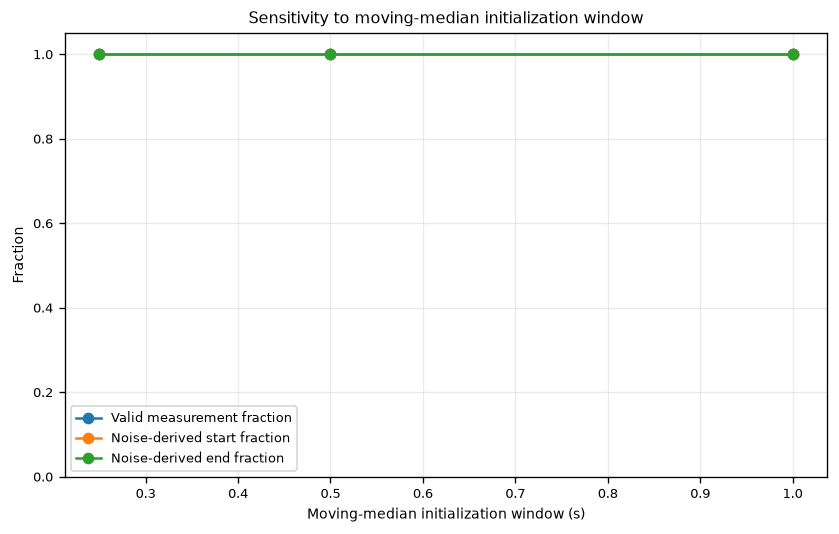

In [24]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(
    window_summary["moving_median_window_s"],
    window_summary["valid_fraction"],
    marker="o",
    label="Valid measurement fraction",
)
ax.plot(
    window_summary["moving_median_window_s"],
    window_summary["noise_return_start_fraction"],
    marker="o",
    label="Noise-derived start fraction",
)
ax.plot(
    window_summary["moving_median_window_s"],
    window_summary["noise_return_end_fraction"],
    marker="o",
    label="Noise-derived end fraction",
)
ax.set_xlabel("Moving-median initialization window (s)")
ax.set_ylabel("Fraction")
ax.set_ylim(0, 1.05)
ax.set_title("Sensitivity to moving-median initialization window")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    SUMMARY_PLOT_DIR
    / "moving_median_window_success_fractions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

The preferred initialization window is chosen primarily by measurement success
and stability, not by maximizing amplitude. A long window that leaves the pulse
intact is generally preferable.

In [25]:
preferred_window_row = (
    window_summary
    .sort_values(
        [
            "valid_fraction",
            "median_baseline_fit_rms_pa",
            "moving_median_window_s",
        ],
        ascending=[False, True, False],
    )
    .iloc[0]
)

PREFERRED_MOVING_MEDIAN_WINDOW_S = float(
    preferred_window_row["moving_median_window_s"]
)

print(
    "Preferred moving-median initialization window:",
    PREFERRED_MOVING_MEDIAN_WINDOW_S,
    "s",
)

Preferred moving-median initialization window: 1.0 s


## 13. Final preferred measurements

In [26]:
preferred_measurements = baseline_measurements_long.loc[
    baseline_measurements_long[
        "moving_median_window_s"
    ].eq(PREFERRED_MOVING_MEDIAN_WINDOW_S)
].copy()

preferred_measurements.to_csv(
    DERIVED_OUTPUT_DIR / "preferred_local_baseline_measurements.csv",
    index=False,
)

display(
    preferred_measurements[
        [
            "reconstructed_event_number",
            "waveform_type",
            "valid_measurement",
            "positive_peak_pa",
            "negative_peak_pa",
            "peak_to_peak_pa",
            "positive_negative_lag_s",
            "event_start_s",
            "event_end_s",
            "event_duration_s",
            "baseline_slope_pa_per_s",
            "baseline_fit_rms_pa",
            "pressure_impulse_pa_s",
        ]
    ].head(20)
)

,reconstructed_event_number,waveform_type,valid_measurement,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_negative_lag_s,event_start_s,event_end_s,event_duration_s,baseline_slope_pa_per_s,baseline_fit_rms_pa,pressure_impulse_pa_s
2,18,HD1,True,180.042081,-36.746379,216.788460,0.024,-0.018063,0.053937,0.072,-273.672533,8.976565,3.421915
5,18,HD2,True,207.468976,-34.494075,241.963051,0.028,-0.018063,0.085938,0.104,-291.558729,6.730717,4.115312
8,18,HD3,True,190.855346,-39.903669,230.759015,0.024,-0.022063,0.069937,0.092,-283.085849,6.744348,3.731045
11,18,median_stack,True,203.464441,-34.494075,237.958516,0.028,-0.018063,0.085938,0.104,-291.558729,6.730717,3.854083
14,83,HD1,True,39.935844,-27.972607,67.908451,0.020,-0.006938,0.053062,0.060,-51.461010,3.329654,0.224777
17,83,HD2,True,50.873220,-31.066697,81.939917,0.024,-0.038938,0.073062,0.112,-23.458256,1.021412,0.395533
20,83,HD3,True,43.707594,-33.787910,77.495504,0.020,-0.010937,0.077063,0.088,-1.737367,1.971705,0.238337
23,83,median_stack,True,43.707594,-33.787910,77.495504,0.020,-0.010937,0.077063,0.088,-1.737367,1.971705,0.192902
26,54,HD1,True,128.307496,-107.972881,236.280377,0.028,-0.010062,0.081938,0.092,-255.578116,19.461334,1.064055
29,54,HD2,True,132.220240,-137.244993,269.465232,0.028,-0.006062,0.109938,0.116,-13.394126,17.690356,-0.142105


## 14. Detailed diagnostic figure

For each selected event, the figure shows:

1. raw unfiltered pressure and the moving-median baseline;
2. raw pressure and the final local linear baseline;
3. final baseline-corrected pressure with refined boundaries and peaks;
4. the same measurements for the unfiltered median stack.

The baseline-fit windows are shaded separately from the event interval.

In [27]:
def add_measurement_annotations(
    axis,
    cached: dict,
):
    times_s = cached["times_s"]
    raw = cached["raw_values"]
    moving_baseline = cached["moving_median_baseline"]
    local_baseline = cached["local_baseline"]
    corrected = cached["corrected_values"]

    axis.plot(
        times_s,
        raw,
        linewidth=0.9,
        label="Raw pressure",
    )
    axis.plot(
        times_s,
        moving_baseline,
        linewidth=1.0,
        linestyle=":",
        label="Moving median",
    )

    if cached["valid_measurement"]:
        axis.plot(
            times_s,
            local_baseline,
            linewidth=1.1,
            linestyle="--",
            label="Local linear baseline",
        )

        axis.axvspan(
            cached["baseline_pre_start_s"],
            cached["baseline_pre_end_s"],
            alpha=0.12,
            label="Baseline-fit samples",
        )
        axis.axvspan(
            cached["baseline_post_start_s"],
            cached["baseline_post_end_s"],
            alpha=0.12,
        )
        axis.axvspan(
            cached["event_start_s"],
            cached["event_end_s"],
            alpha=0.09,
            label="Measured event",
        )

        axis.scatter(
            [cached["positive_time_s"]],
            [
                np.interp(
                    cached["positive_time_s"],
                    times_s,
                    raw,
                )
            ],
            s=44,
            zorder=6,
        )
        axis.scatter(
            [cached["negative_time_s"]],
            [
                np.interp(
                    cached["negative_time_s"],
                    times_s,
                    raw,
                )
            ],
            s=44,
            zorder=6,
        )

    axis.axvline(0.0, linewidth=0.7, alpha=0.7)
    axis.grid(True, axis="x", alpha=0.25)


def build_event_baseline_diagnostic(
    event_number: int,
):
    waveform_types = [*INFRASOUND_CHANNELS, "median_stack"]

    fig, axes = plt.subplots(
        len(waveform_types),
        2,
        figsize=(12.2, 9.2),
        sharex=True,
        constrained_layout=True,
    )

    for row_index, waveform_type in enumerate(waveform_types):
        cached = measurement_cache[
            (
                event_number,
                waveform_type,
                PREFERRED_MOVING_MEDIAN_WINDOW_S,
            )
        ]

        raw_axis = axes[row_index, 0]
        corrected_axis = axes[row_index, 1]

        add_measurement_annotations(
            raw_axis,
            cached,
        )

        raw_axis.text(
            0.015,
            0.86,
            waveform_type,
            transform=raw_axis.transAxes,
            fontweight="bold",
            va="top",
        )

        if cached["valid_measurement"]:
            corrected_axis.plot(
                cached["times_s"],
                cached["corrected_values"],
                linewidth=1.0,
            )
            corrected_axis.axhline(
                0.0,
                linewidth=0.6,
                alpha=0.6,
            )
            corrected_axis.axvline(
                0.0,
                linewidth=0.7,
                alpha=0.7,
            )
            corrected_axis.axvspan(
                cached["event_start_s"],
                cached["event_end_s"],
                alpha=0.09,
            )
            corrected_axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=48,
                zorder=6,
                label="Positive peak",
            )
            corrected_axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=48,
                zorder=6,
                label="Negative peak",
            )
            corrected_axis.axvline(
                cached["event_start_s"],
                linestyle="--",
                linewidth=0.8,
            )
            corrected_axis.axvline(
                cached["event_end_s"],
                linestyle="--",
                linewidth=0.8,
            )

            summary_text = (
                f"+{cached['positive_peak_pa']:.2f} Pa at "
                f"{cached['positive_time_s']:.3f} s\n"
                f"{cached['negative_peak_pa']:.2f} Pa at "
                f"{cached['negative_time_s']:.3f} s\n"
                f"p-p {cached['peak_to_peak_pa']:.2f} Pa; "
                f"lag {cached['positive_negative_lag_s']:.3f} s\n"
                f"duration {cached['event_duration_s']:.3f} s; "
                f"impulse {cached['pressure_impulse_pa_s']:.3g} Pa s"
            )
        else:
            summary_text = (
                f"Invalid: {cached['failure_reason']}"
            )

        corrected_axis.text(
            0.985,
            0.95,
            summary_text,
            transform=corrected_axis.transAxes,
            ha="right",
            va="top",
            fontsize=7.0,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "0.7",
                "alpha": 0.92,
            },
        )

        corrected_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

    axes[0, 0].set_title(
        "Unfiltered pressure and baseline estimates",
        fontweight="bold",
    )
    axes[0, 1].set_title(
        "Local-baseline-corrected pressure",
        fontweight="bold",
    )

    for axis in axes[:, 0]:
        axis.set_ylabel("Pressure (Pa)")

    axes[-1, 0].set_xlabel(
        "Reduced time relative to event (s)"
    )
    axes[-1, 1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    event_row = selected_events.loc[
        selected_events["reconstructed_event_number"]
        == event_number
    ].iloc[0]

    fig.suptitle(
        f"Reconstructed event {event_number:03d}: "
        f"unfiltered local-baseline measurement\n"
        f"initial median-stack SNR "
        f"{event_row['median_stack_snr']:.1f}; "
        f"initial peak {event_row['peak_median_stack_pa']:.1f} Pa; "
        f"moving-median initialization "
        f"{PREFERRED_MOVING_MEDIAN_WINDOW_S:g} s",
        fontweight="bold",
    )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=4,
            bbox_to_anchor=(0.5, -0.012),
            frameon=False,
        )

    return fig

## 15. Generate diagnostic PNGs

In [28]:
if WRITE_EVENT_DIAGNOSTIC_PNGS:
    for index, event_number in enumerate(
        selected_events[
            "reconstructed_event_number"
        ].astype(int),
        start=1,
    ):
        figure = build_event_baseline_diagnostic(
            event_number
        )
        outfile = (
            EVENT_PLOT_DIR
            / f"event_{event_number:03d}_local_baseline.png"
        )
        figure.savefig(
            outfile,
            dpi=220,
            bbox_inches="tight",
        )
        plt.close(figure)

        if (
            index == 1
            or index % 5 == 0
            or index == len(selected_events)
        ):
            print(
                f"Generated {index} of "
                f"{len(selected_events)} diagnostic figures"
            )

Generated 1 of 24 diagnostic figures
Generated 5 of 24 diagnostic figures
Generated 10 of 24 diagnostic figures
Generated 15 of 24 diagnostic figures
Generated 20 of 24 diagnostic figures
Generated 24 of 24 diagnostic figures


## 16. Preview one event

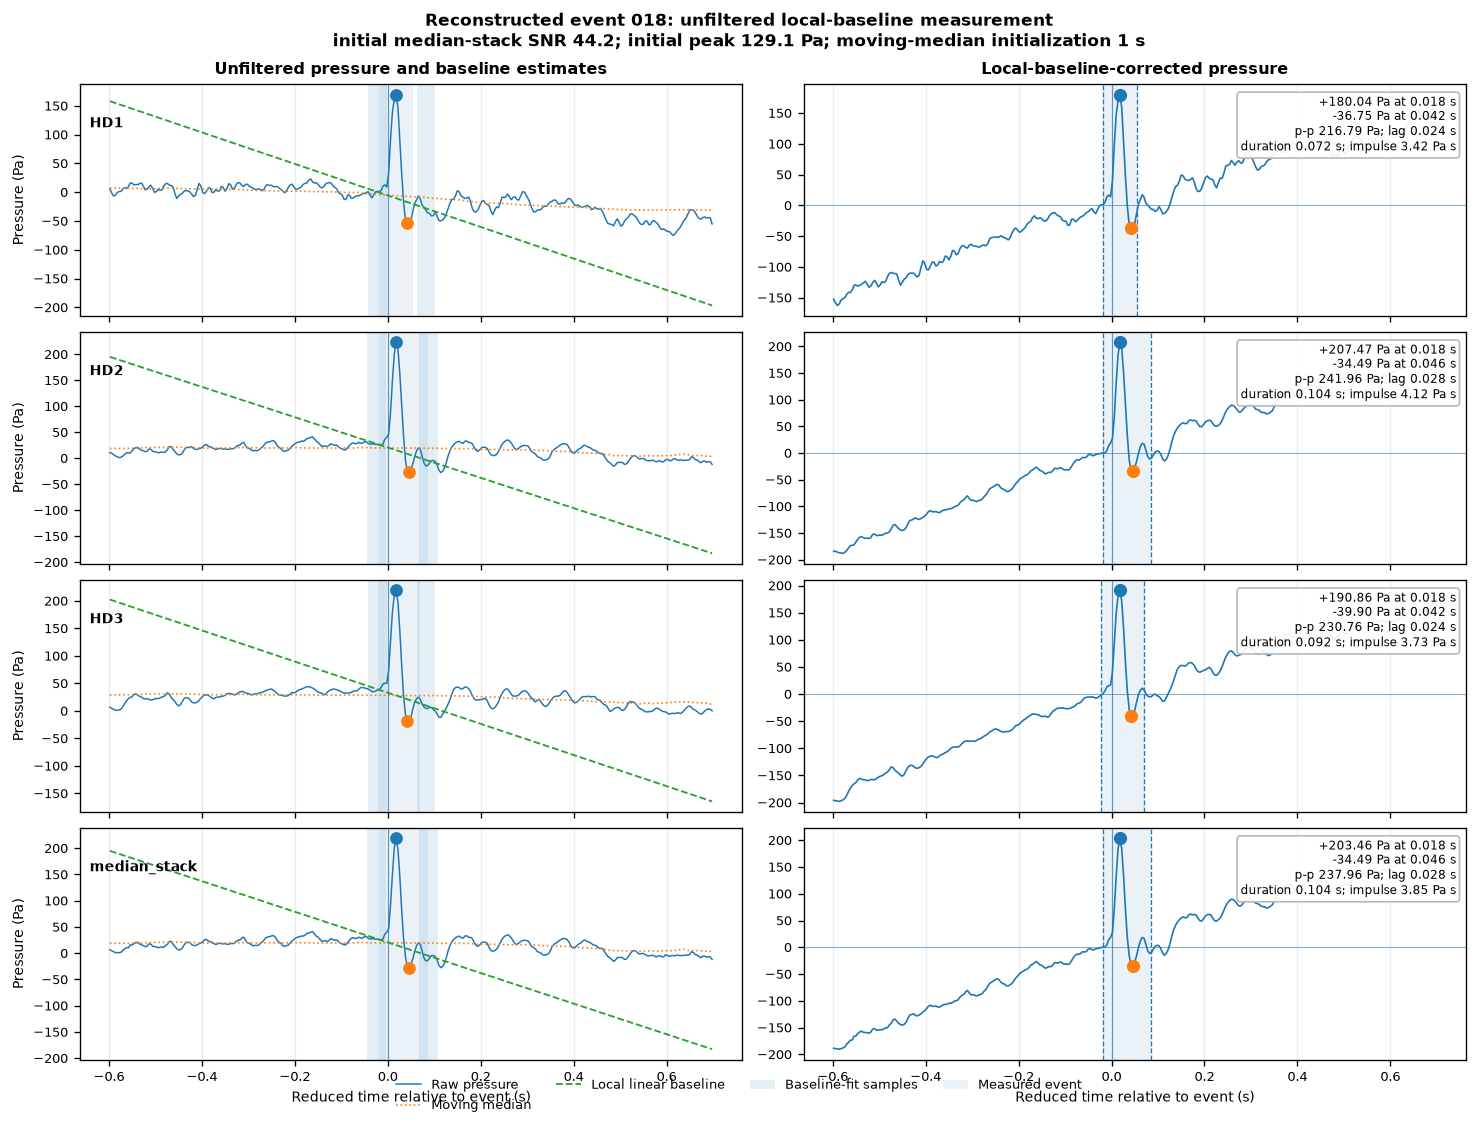

In [29]:
PREVIEW_EVENT_NUMBER = int(
    selected_events.iloc[0][
        "reconstructed_event_number"
    ]
)

preview_figure = build_event_baseline_diagnostic(
    PREVIEW_EVENT_NUMBER
)
plt.show()

## 17. Cross-channel measurement consistency

A physically credible baseline method should produce broadly consistent peak
times, lag, duration, and pressure across HD1–HD3 after differential shifting.
The following tables quantify that event-by-event scatter.

In [30]:
channel_measurements = preferred_measurements.loc[
    preferred_measurements["waveform_type"].isin(
        INFRASOUND_CHANNELS
    )
    & preferred_measurements["valid_measurement"]
].copy()

event_consistency = (
    channel_measurements
    .groupby("reconstructed_event_number")
    .agg(
        channel_count=("waveform_type", "nunique"),
        median_positive_peak_pa=("positive_peak_pa", "median"),
        positive_peak_range_pa=(
            "positive_peak_pa",
            lambda x: x.max() - x.min(),
        ),
        median_negative_peak_pa=("negative_peak_pa", "median"),
        negative_peak_range_pa=(
            "negative_peak_pa",
            lambda x: x.max() - x.min(),
        ),
        median_peak_to_peak_pa=("peak_to_peak_pa", "median"),
        peak_to_peak_cv=(
            "peak_to_peak_pa",
            lambda x: (
                x.std(ddof=1) / x.mean()
                if len(x) > 1 and x.mean() != 0
                else np.nan
            ),
        ),
        positive_time_range_s=(
            "positive_time_s",
            lambda x: x.max() - x.min(),
        ),
        negative_time_range_s=(
            "negative_time_s",
            lambda x: x.max() - x.min(),
        ),
        median_lag_s=("positive_negative_lag_s", "median"),
        lag_range_s=(
            "positive_negative_lag_s",
            lambda x: x.max() - x.min(),
        ),
        median_duration_s=("event_duration_s", "median"),
    )
    .reset_index()
)

display(event_consistency)

event_consistency.to_csv(
    DERIVED_OUTPUT_DIR
    / "local_baseline_cross_channel_consistency.csv",
    index=False,
)

,reconstructed_event_number,channel_count,median_positive_peak_pa,positive_peak_range_pa,median_negative_peak_pa,negative_peak_range_pa,median_peak_to_peak_pa,peak_to_peak_cv,positive_time_range_s,negative_time_range_s,median_lag_s,lag_range_s,median_duration_s
0,9,3,109.365581,7.632665,-71.922439,9.775246,178.157701,0.014857,0.004,0.004,0.028,3.999949e-03,0.072
1,13,1,92.830694,0.000000,-6.205021,0.000000,99.035715,NaN,0.000,0.000,0.008,0.000000e+00,0.024
2,15,1,5.133525,0.000000,-263.017310,0.000000,268.150835,NaN,0.000,0.000,0.160,0.000000e+00,0.176
3,18,3,190.855346,27.426896,-36.746379,5.409594,230.759015,0.054876,0.000,0.004,0.024,3.999949e-03,0.092
4,22,3,267.621856,13.845437,-119.496615,24.642525,387.118470,0.053203,0.004,0.004,0.044,0.000000e+00,0.108
5,23,3,293.485540,19.318988,-106.269908,14.702331,399.755449,0.042843,0.004,0.004,0.112,2.384186e-07,0.176
6,24,3,247.836757,32.808533,-77.409874,29.570054,325.246631,0.096192,0.004,0.004,0.100,2.384186e-07,0.140
7,25,3,96.620693,9.753044,-96.714701,10.077045,188.715836,0.014543,0.004,0.004,0.036,0.000000e+00,0.096
8,34,3,39.527715,18.901939,-16.476992,65.529114,56.817344,0.376727,0.004,0.068,0.104,7.200027e-02,0.196
9,37,3,34.573177,6.557761,-35.577021,17.091296,70.150198,0.076577,0.004,0.160,0.024,1.560001e-01,0.076


## 18. Summary figures

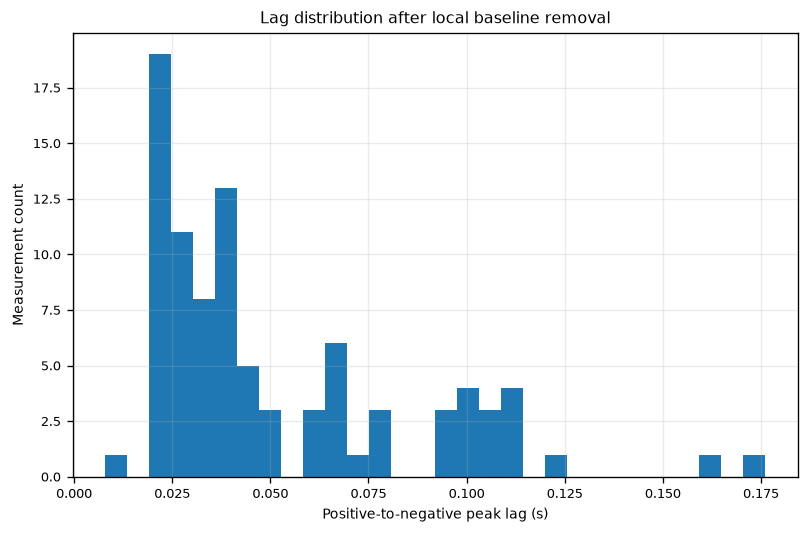

In [31]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.hist(
    preferred_measurements.loc[
        preferred_measurements["valid_measurement"],
        "positive_negative_lag_s",
    ],
    bins=30,
)
ax.set_xlabel("Positive-to-negative peak lag (s)")
ax.set_ylabel("Measurement count")
ax.set_title("Lag distribution after local baseline removal")
ax.grid(True, alpha=0.25)

fig.savefig(
    SUMMARY_PLOT_DIR / "positive_negative_lag_histogram.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

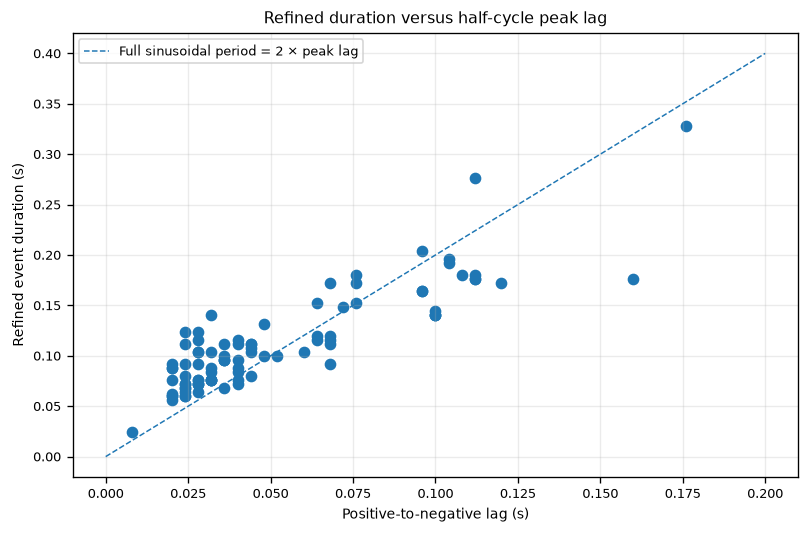

In [32]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.scatter(
    preferred_measurements.loc[
        preferred_measurements["valid_measurement"],
        "positive_negative_lag_s",
    ],
    preferred_measurements.loc[
        preferred_measurements["valid_measurement"],
        "event_duration_s",
    ],
)
ax.plot(
    [0, 0.2],
    [0, 0.4],
    linestyle="--",
    linewidth=0.9,
    label="Full sinusoidal period = 2 × peak lag",
)
ax.set_xlabel("Positive-to-negative lag (s)")
ax.set_ylabel("Refined event duration (s)")
ax.set_title("Refined duration versus half-cycle peak lag")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    SUMMARY_PLOT_DIR / "duration_vs_peak_lag.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 19. Interpretation

The local linear baseline is intended for physical pressure measurements because
it avoids frequency-dependent filtering. The moving median is only an
initialization method.

Before applying this method to all reconstructed events, inspect:

- whether the moving-median baseline remains smooth across each pulse;
- whether the exterior baseline windows are uncontaminated by neighboring
  events;
- whether the fitted linear baseline crosses the raw waveform plausibly;
- whether the refined boundaries correspond to visual returns to noise;
- whether positive and negative peaks remain coherent across channels;
- whether very large baseline slopes indicate a failed or contaminated fit.

Events with failed fits or nearby overlapping arrivals should retain explicit
quality flags and may require manually adjusted baseline windows.